In [1]:
import dnnlib.nlb_util_v2 as nlb_util
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
def plot_frame(data, T, trial_idx, mean_image, n_img = 6):
    idxs = np.linspace(0, T-1, n_img, dtype=int)
    fig, axes = plt.subplots(1, len(idxs), figsize=(12, 2))
    for ax, i in zip(axes, idxs):
        if mean_image is not None:
            ax.imshow(data[trial_idx][i,0,:,:] + mean_image, cmap = 'gray')
        else:
            ax.imshow(data[trial_idx][i,0,:,:], cmap = 'gray')
        ax.set_title(f"t={i}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
def sigma_for_psnr(x, psnr_db=35, peak=None):
    if peak is None:
        lo, hi = np.percentile(x, 0.5), np.percentile(x, 99.5)  # robust dynamic range
        peak = hi - lo
    return peak * (10**(-psnr_db/20))

In [3]:
print(os.getcwd())

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt


In [4]:
dir_old = os.getcwd()
os.chdir('/home/ganchao')
folderpath = 'isilon/AllStaff/mice/mSM49/SpatialDisc/30-Jul-2018/BehaviorVideo'

In [5]:
# end_V = 89928//10
# print(end_V)
end_V = 89928
frame_resize_ratio = 64/320

In [6]:
train_dataloader, val_dataloader, train_video, _,mean_image = nlb_util.loder_musall_behavior(folderpath,
                                                                                             frame_resize_ratio = frame_resize_ratio)

Reconstruct 89928 frame of video..
Finished reconstructing segment 1
Finished reconstructing segment 2
Finished reconstructing segment 3
Finished reconstructing segment 4
Finished reconstructing segment 5
Finished reconstructing segment 6
Finished reconstructing segment 7
Finished reconstructing segment 8
Finished reconstructing segment 9
Finished reconstructing segment 10
Finished reconstructing segment 11
Finished reconstructing segment 12
Finished reconstructing segment 13
Finished reconstructing segment 14
Finished reconstructing segment 15
Finished reconstructing segment 16
processed video shape: (frame, x, y) (89928, 48, 64)
make each frame a square..
padding each frame..
finish loading videos


In [7]:
train_video.shape

(71942, 64, 64)

In [8]:
train_video_5d = train_video[np.newaxis, :, np.newaxis, :, :]
x_min, x_max = np.min(train_video_5d), np.max(train_video_5d)  # from you
x = train_video_5d
x_norm = 2.0 * (x - x_min) / (x_max - x_min) - 1.0   # -> in [-1, 1]
mean_image_norm = 2.0 * (mean_image - x_min) / (x_max - x_min) - 1.0

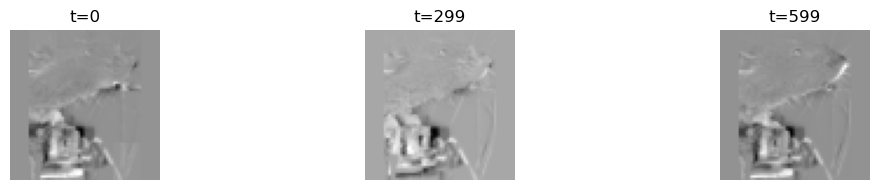

In [12]:
plot_frame(x_norm, 600, 0, None, 3)

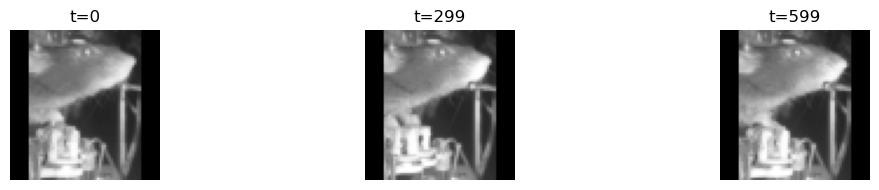

In [9]:
plot_frame(x_norm, 600, 0, mean_image_norm, 3)

In [12]:
train_video_5d.shape

(1, 71942, 1, 160, 160)

In [13]:
os.chdir(dir_old)

In [14]:
1/30, np.max(x_norm), np.min(x_norm)

(0.03333333333333333, 1.0, -1.0)

Let's see how much noise I can use.

0.08003345683371176


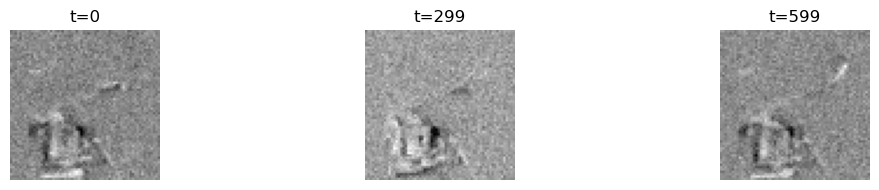

In [17]:
sigma = sigma_for_psnr(x_norm, psnr_db=20)
print(sigma)
dset_samples_noise = x_norm.copy()
dset_samples_noise = x_norm + np.random.normal(scale=sigma, size=x_norm.shape)
plot_frame(dset_samples_noise, 600, 0, None, 3)

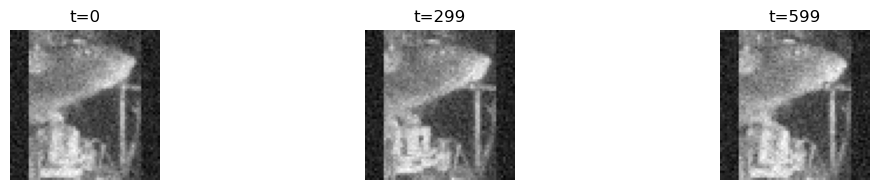

In [18]:
plot_frame(dset_samples_noise, 600, 0, mean_image_norm, 3)

In [16]:
img5d = x_norm.astype(np.float32, copy=False)
# np.savez("data/musal_behavior/dataset_samples.npz", samples=img5d)
# np.save("data/musal_behavior/mean_image.npy", mean_image_norm)

# np.savez("data/musal_behavior2/dataset_samples.npz", samples=img5d)
# np.save("data/musal_behavior2/mean_image.npy", mean_image_norm)


np.savez("data/musal_behavior_HD/dataset_samples.npz", samples=img5d)
np.save("data/musal_behavior_HD/mean_image.npy", mean_image_norm)

In [18]:
img5d.shape

(1, 71942, 1, 160, 160)